In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = 'fauziaannisa'  # ganti sama username kaggle kamu
os.environ['KAGGLE_KEY'] = 'KGAT_e45808d8fa32ce96a4f7954dbae9a456' # token kamu

In [ ]:
!pip install kaggle -q
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:20<00:00, 117MB/s]



In [ ]:
!unzip -q chest-xray-pneumonia.zip -d /content/chest_xray
!ls /content/chest_xray

chest_xray


In [ ]:
import os
print("Isi /content/chest_xray:")
print(os.listdir('/content/chest_xray'))

Isi /content/chest_xray:
['chest_xray']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# CATAT: TAMBAH /chest_xray LAGI
train_data = train_datagen.flow_from_directory(
    '/content/chest_xray/chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = train_datagen.flow_from_directory(
    '/content/chest_xray/chest_xray/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_data = train_datagen.flow_from_directory(
    '/content/chest_xray/chest_xray/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

print("Classes:", train_data.class_indices)
print("Total train images:", train_data.samples)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Total train images: 5216


In [ ]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Training V1...")
history1 = model.fit(train_data, validation_data=val_data, epochs=5)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training V1...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 692ms/step - accuracy: 0.7372 - loss: 0.5686 - val_accuracy: 0.5000 - val_loss: 0.7244
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 665ms/step - accuracy: 0.7479 - loss: 0.5240 - val_accuracy: 0.5625 - val_loss: 0.6730
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 650ms/step - accuracy: 0.7548 - loss: 0.4808 - val_accuracy: 0.5000 - val_loss: 0.7880
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 659ms/step - accuracy: 0.7650 - loss: 0.4615 - val_accuracy: 0.5625 - val_loss: 0.8496
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 646ms/step - accuracy: 0.7579 - loss: 0.4387 - val_accuracy: 0.5625 - val_loss: 0.7473


In [ ]:
base_model.trainable = True # buka layer

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Training V2...")
history2 = model.fit(train_data, validation_data=val_data, epochs=5)

Training V2...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 181s 781ms/step - accuracy: 0.7788 - loss: 0.5609 - val_accuracy: 0.5000 - val_loss: 0.7221
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 755ms/step - accuracy: 0.9327 - loss: 0.1700 - val_accuracy: 0.5000 - val_loss: 1.1632
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 125s 764ms/step - accuracy: 0.9588 - loss: 0.1224 - val_accuracy: 0.5000 - val_loss: 1.8381
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 757ms/step - accuracy: 0.9670 - loss: 0.0936 - val_accuracy: 0.5000 - val_loss: 4.4360
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 760ms/step - accuracy: 0.9755 - loss: 0.0694 - val_accuracy: 0.5000 - val_loss: 3.5811


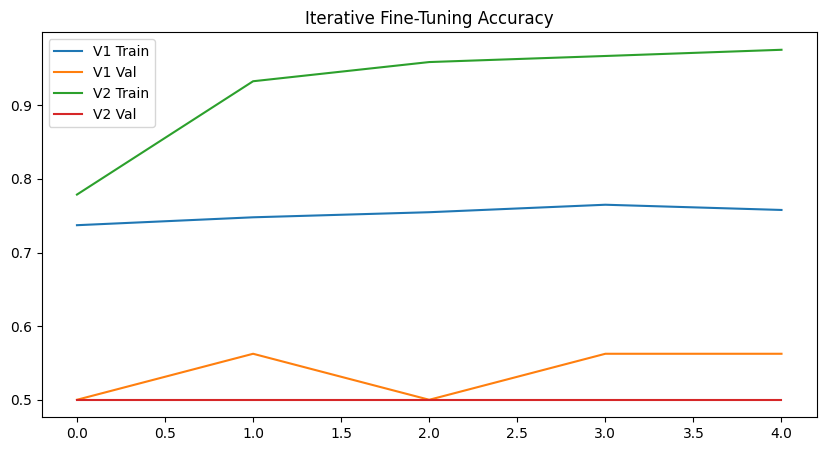

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history1.history['accuracy'], label='V1 Train')
plt.plot(history1.history['val_accuracy'], label='V1 Val')
plt.plot(history2.history['accuracy'], label='V2 Train')
plt.plot(history2.history['val_accuracy'], label='V2 Val')
plt.legend()
plt.title('Iterative Fine-Tuning Accuracy')
plt.show()